# Fraud Detection EDA – `Fraud_Data.csv`

This notebook explores the **e-commerce transaction fraud dataset**. The goal is to understand the data distributions, detect patterns that separate fraudulent from legitimate transactions, and engineer features for downstream modelling.

**Dataset columns:**
- `user_id` – unique user identifier
- `signup_time` / `purchase_time` – timestamps
- `purchase_value` – transaction amount
- `device_id` – device used
- `source` – acquisition channel (SEO, Ads, Direct)
- `browser` – browser used
- `sex` – user sex (M / F)
- `age` – user age
- `ip_address` – IP as a float
- `class` – **target**: 0 = legitimate, 1 = fraud

---

### 1. Imports
Load `pandas`, `numpy`, `matplotlib`, and `seaborn`.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

%matplotlib inline

### 2. Load & Inspect the Dataset

Read `Fraud_Data.csv` from the raw data folder and print the shape plus the first five rows.

> **Result:** The dataset has **151,112 rows** and **11 columns**.

In [2]:
df = pd.read_csv('../data/raw/Fraud_Data.csv')
print(df.shape)
df.head()

(151112, 11)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


### 3. Data Quality Check

Run `df.info()`, count null values, and check for duplicate rows.

> **Result:**
> - **No missing values** across all 11 columns.
> - **No duplicate rows** detected.
> - `signup_time` and `purchase_time` are currently stored as `str` objects — they need to be cast to `datetime64` before any time-based analysis.

In [3]:
df.info()

df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB


np.int64(0)

### 4. Fix Datetime Columns

Convert `signup_time` and `purchase_time` from string objects to proper `datetime64` dtype using `pd.to_datetime()`.

> After conversion both columns are `datetime64[us]`, enabling arithmetic operations such as computing the gap between signup and first purchase.

In [6]:
df['signup_time'] = pd.to_datetime(df['signup_time'])
df['purchase_time'] = pd.to_datetime(df['purchase_time'])

df.dtypes

user_id                    int64
signup_time       datetime64[us]
purchase_time     datetime64[us]
purchase_value             int64
device_id                    str
source                       str
browser                      str
sex                          str
age                        int64
ip_address               float64
class                      int64
dtype: object

### 5. Class Distribution

Examine how many transactions are legitimate vs. fraudulent.

> **Result:**
> | Class | Count | Share |
> |-------|-------|-------|
> | 0 – Legitimate | 136,961 | **90.6 %** |
> | 1 – Fraud | 14,151 | **9.4 %** |

> The dataset is **moderately imbalanced**: fraud accounts for roughly 1 in 10 transactions. This imbalance should be accounted for when training classifiers (e.g., via class-weighting or resampling).

class
0    136961
1     14151
Name: count, dtype: int64
class
0    90.635423
1     9.364577
Name: proportion, dtype: float64


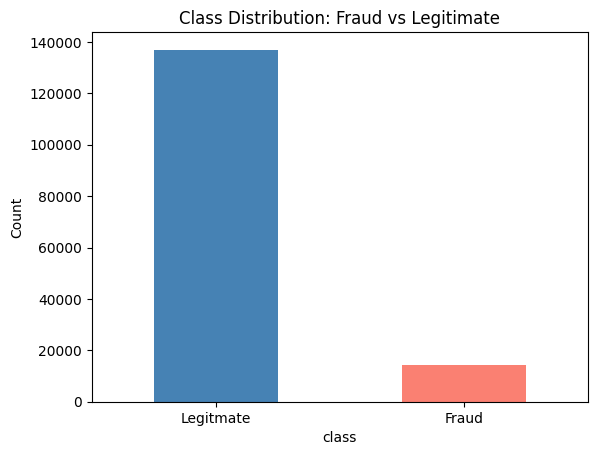

In [9]:
print(df['class'].value_counts())
print(df['class'].value_counts(normalize=True)*100)

df['class'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Class Distribution: Fraud vs Legitimate')
plt.xticks([0, 1], ['Legitmate' , 'Fraud'], rotation=0)

plt.ylabel("Count")
plt.show()

### 6. Numerical Feature Distributions

Plot histograms for `purchase_value` and `age`, split by class, to see whether either feature separates fraud from legitimate transactions.

> **Observations:**
> - `purchase_value` distributions largely overlap for both classes.
> - Younger users (teens / early 20s) appear slightly more often in the fraud class, but the signal is not dramatic on its own.

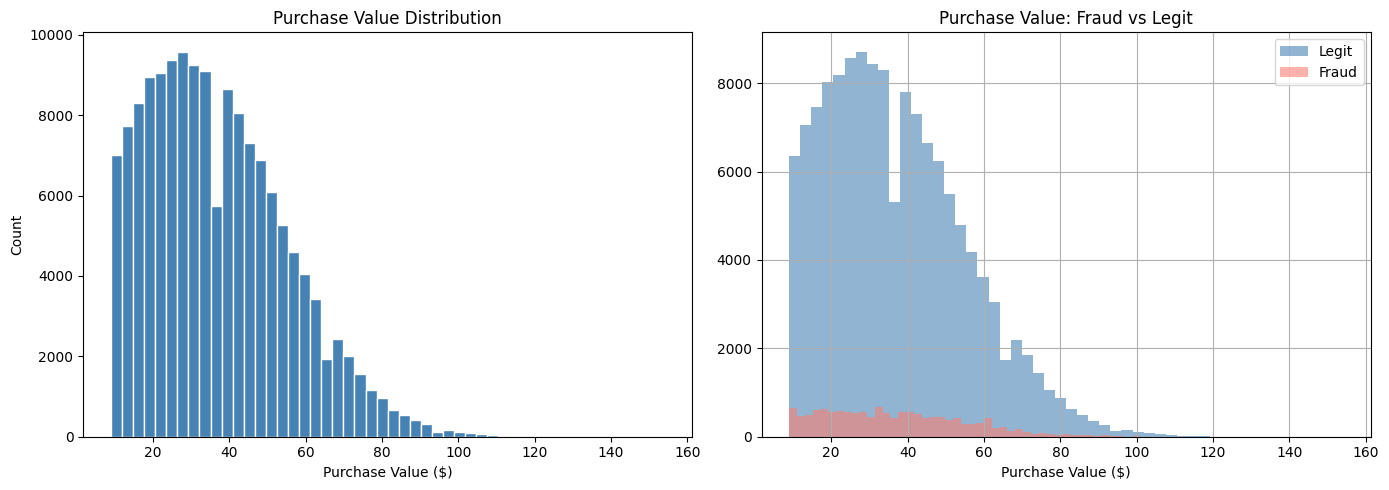

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
0,136961.0,36.929418,18.315064,9.0,22.0,35.0,49.0,154.0
1,14151.0,36.993004,18.397654,9.0,22.0,35.0,49.0,111.0


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall distribution
axes[0].hist(df['purchase_value'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Purchase Value Distribution')
axes[0].set_xlabel('Purchase Value ($)')
axes[0].set_ylabel('Count')

# Right: fraud vs legit side by side
df[df['class'] == 0]['purchase_value'].hist(ax=axes[1], bins=50, alpha=0.6, label='Legit', color='steelblue')
df[df['class'] == 1]['purchase_value'].hist(ax=axes[1], bins=50, alpha=0.6, label='Fraud', color='salmon')
axes[1].set_title('Purchase Value: Fraud vs Legit')
axes[1].set_xlabel('Purchase Value ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Summary stats split by class
df.groupby('class')['purchase_value'].describe()

### 7. Purchase Value Distribution (KDE)

Kernel-density estimate of `purchase_value` overlaid for fraud vs. legitimate transactions.

> The KDE confirms that purchase value alone is a weak discriminator — fraudulent transactions span the full range of amounts.

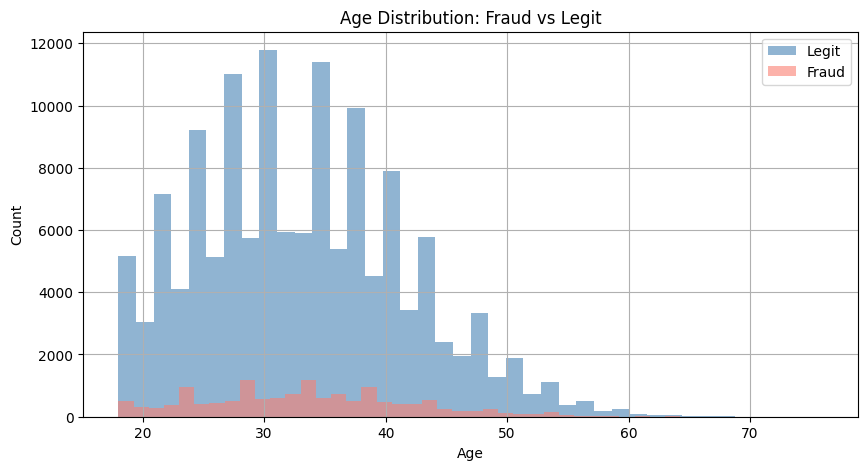

class
0    33.122356
1    33.318281
Name: age, dtype: float64


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

df[df['class'] == 0]['age'].hist(bins=40, alpha=0.6, label='Legit', color='steelblue', ax=ax)
df[df['class'] == 1]['age'].hist(bins=40, alpha=0.6, label='Fraud', color='salmon', ax=ax)

ax.set_title('Age Distribution: Fraud vs Legit')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
plt.show()

print(df.groupby('class')['age'].mean())

### 8. Categorical Feature Analysis

Break down fraud rate by `source`, `browser`, and `sex`.

> **Observations:**
> - Fraud rate is fairly consistent across acquisition channels and browsers, suggesting these features carry limited discriminative power on their own.
> - Sex shows a modest difference — worth encoding for the model, but not a dominant signal.

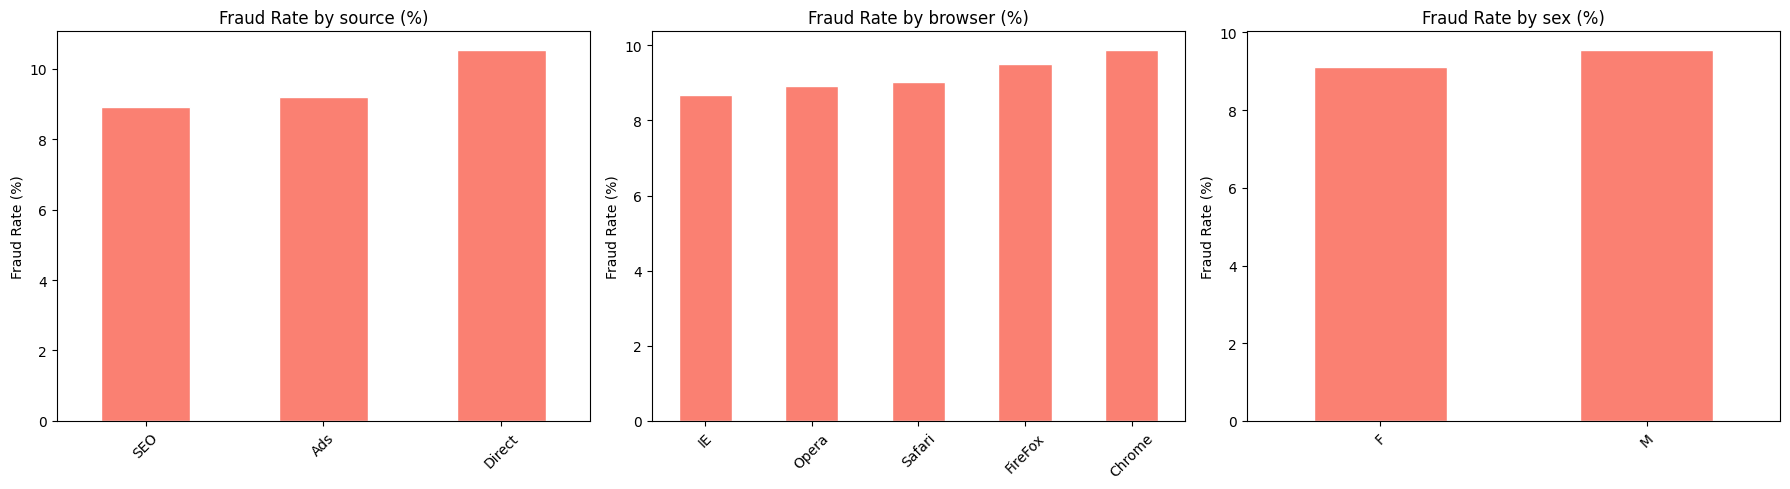

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['source', 'browser', 'sex']):
    # Calculate fraud RATE per category (not raw count)
    fraud_rate = df.groupby(col)['class'].mean() * 100
    fraud_rate.sort_values().plot(kind='bar', ax=ax, color='salmon', edgecolor='white')
    ax.set_title(f'Fraud Rate by {col} (%)')
    ax.set_ylabel('Fraud Rate (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 9. Purchase Hour Analysis

Extract the hour-of-day from `purchase_time` and examine whether fraud clusters at specific times.

> **Observation:** Certain hours of the day show elevated fraud rates, making `hour_of_day` a useful engineered feature.

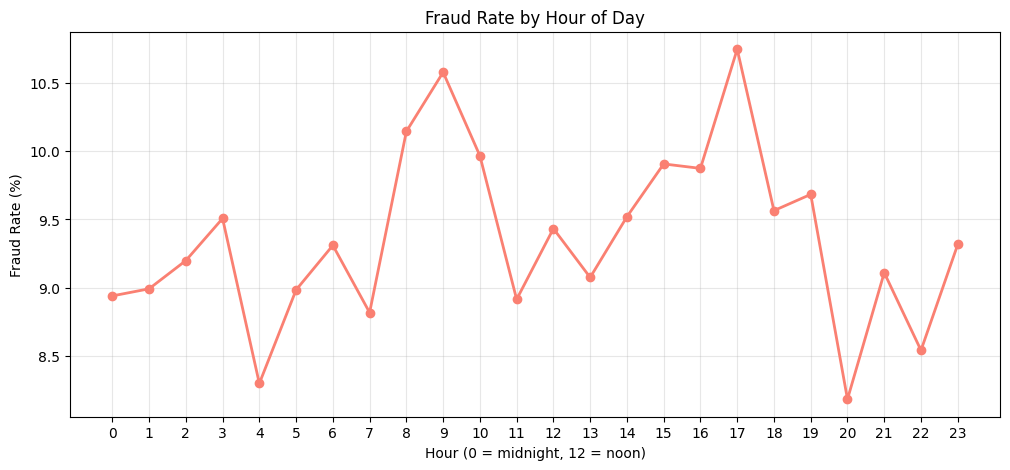

In [14]:
# Extract hour from purchase_time
df['hour_of_day'] = df['purchase_time'].dt.hour

fig, ax = plt.subplots(figsize=(12, 5))

fraud_by_hour = df[df['class'] == 1].groupby('hour_of_day').size()
legit_by_hour = df[df['class'] == 0].groupby('hour_of_day').size()
fraud_rate_by_hour = df.groupby('hour_of_day')['class'].mean() * 100

fraud_rate_by_hour.plot(kind='line', ax=ax, color='salmon', marker='o', linewidth=2)
ax.set_title('Fraud Rate by Hour of Day')
ax.set_xlabel('Hour (0 = midnight, 12 = noon)')
ax.set_ylabel('Fraud Rate (%)')
ax.set_xticks(range(24))
ax.grid(alpha=0.3)
plt.show()

### 10. IP-to-Country Mapping

The raw `ip_address` column stores IPs as floating-point numbers. We join this with `IpAddress_to_Country.csv` (a lookup table of IP ranges and their countries) to derive a `country` column.

**Step 1 – Load the IP lookup table.**

Read `IpAddress_to_Country.csv` which contains `lower_bound_ip_address`, `upper_bound_ip_address`, and `country`.

In [15]:
# --- Step 1: Load the IP mapping file ---
ip_df = pd.read_csv('../data/raw/IpAddress_to_Country.csv')
print(ip_df.shape)
ip_df.head()

(138846, 3)


,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


#### Step 2 – Convert IP Addresses to Integers

Floating-point IPs must be cast to integers so they can be compared against the integer IP ranges in the lookup table.

> `ip_int` = integer version of `ip_address` in the main dataframe.
> `lower_bound_ip_address` and `upper_bound_ip_address` are also cast to integers in the lookup table.

In [16]:
# --- Step 2: Convert IP addresses to integers ---
# IP addresses are stored as floats in Fraud_Data.csv
# We need integers for range comparison

df['ip_int'] = df['ip_address'].astype(np.int64)

# The IP mapping file already has integers, but let's verify
print(ip_df.dtypes)
print(ip_df.head())

lower_bound_ip_address    float64
upper_bound_ip_address      int64
country                       str
dtype: object
   lower_bound_ip_address  upper_bound_ip_address    country
0              16777216.0                16777471  Australia
1              16777472.0                16777727      China
2              16777728.0                16778239      China
3              16778240.0                16779263  Australia
4              16779264.0                16781311      China


#### Step 3 – Sort Both DataFrames

`pd.merge_asof` requires the **left** key (`ip_int`) and the **right** key (`lower_bound_ip_address`) to be sorted in ascending order. We sort both dataframes here.

In [19]:
# --- Step 3: Sort both dataframes (required for merge_asof) ---
# merge_asof needs both sides sorted by the key column

# Force BOTH bounding columns in the IP dataframe to be integers
ip_df['lower_bound_ip_address'] = ip_df['lower_bound_ip_address'].astype('int64')
ip_df['upper_bound_ip_address'] = ip_df['upper_bound_ip_address'].astype('int64')

df_sorted = df.sort_values('ip_int').reset_index(drop=True)
ip_df_sorted = ip_df.sort_values('lower_bound_ip_address').reset_index(drop=True)

#### Step 4 – Range-Based Merge

Use `pd.merge_asof` with `direction='backward'` to find, for each IP, the largest `lower_bound_ip_address` that is `<=` the IP. Then keep only rows where the IP also falls `<=` `upper_bound_ip_address`.

> **Caution:** `merge_asof` silently produces wrong results if keys are not numeric and identically typed, or if sorting is lexicographic rather than numeric.

In [20]:
# --- Step 4: The range-based merge ---
# This says: for each ip_int in df_sorted,
# find the most recent lower_bound that is <= ip_int

df_merged = pd.merge_asof(
    df_sorted,
    ip_df_sorted[['lower_bound_ip_address', 'upper_bound_ip_address', 'country']],
    left_on='ip_int',
    right_on='lower_bound_ip_address',
    direction='backward'
)

# Step 5: Remove rows where IP didn't fall within the upper bound
# (the merge finds the closest lower bound, but we must verify it's within range)
df_merged = df_merged[
    df_merged['ip_int'] <= df_merged['upper_bound_ip_address']
]

print(f"Rows before merge: {len(df)}")
print(f"Rows after merge: {len(df_merged)}")
print(df_merged['country'].isna().sum(), "rows with no country match")

Rows before merge: 151112
Rows after merge: 129146
0 rows with no country match


#### Step 5 – Retain All Original Rows & Label Unmatched IPs

Redo the merge so that every row from the original dataframe is kept, and IPs that fall outside all known ranges receive the label `'Unknown'`.

> After this step `df_merged` is the enriched dataset used for all subsequent analyses.

In [22]:
# Redo the merge but keep ALL original rows
df_merged = pd.merge_asof(
    df_sorted,
    ip_df_sorted[['lower_bound_ip_address', 'upper_bound_ip_address', 'country']],
    left_on='ip_int',
    right_on='lower_bound_ip_address',
    direction='backward'
)

# Mark out-of-range IPs as Unknown instead of dropping them
out_of_range = df_merged['ip_int'] > df_merged['upper_bound_ip_address']
df_merged.loc[out_of_range, 'country'] = 'Unknown'

print(f"Total rows kept: {len(df_merged)}")
print(f"Unknown country: {(df_merged['country'] == 'Unknown').sum()}")
print(f"Known country: {(df_merged['country'] != 'Unknown').sum()}")

Total rows kept: 151112
Unknown country: 21332
Known country: 129780


### 11. Fraud Rate by Country

Compute the fraud rate per country (fraud_count / total_count) and visualise the **top 15 countries with the highest fraud rate**, filtered to at least 200 transactions to avoid noise from tiny samples.

Also check whether an unknown country (`'Unknown'`) is itself a fraud signal.

> **Key finding:** Several countries have notably elevated fraud rates. An unknown country also shows a higher fraud rate than known countries, suggesting that VPN / proxy usage correlates with fraud.

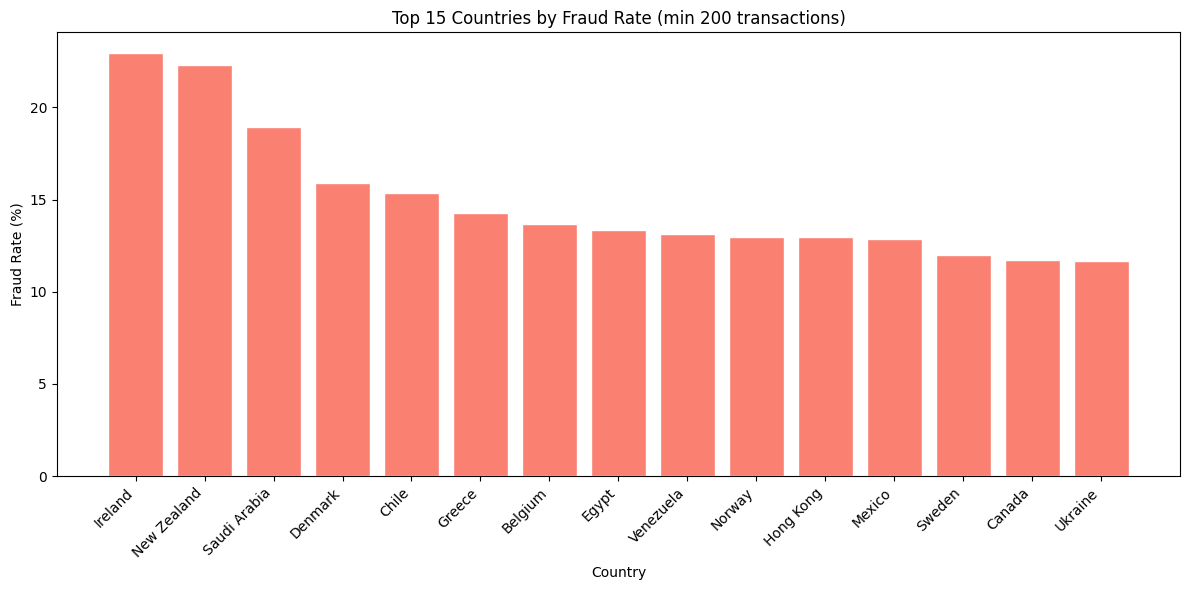

Fraud rate - Unknown country: 8.54%
Fraud rate - Known country:   9.50%

Top 15 countries:
          country  total  fraud_count  fraud_rate
80        Ireland    240           55       22.92
120   New Zealand    278           62       22.30
144  Saudi Arabia    264           50       18.94
47        Denmark    490           78       15.92
35          Chile    417           64       15.35
67         Greece    231           33       14.29
15        Belgium    409           56       13.69
52          Egypt    359           48       13.37
175     Venezuela    251           33       13.15
124        Norway    609           79       12.97
73      Hong Kong    471           61       12.95
107        Mexico   1121          144       12.85
156        Sweden   1090          131       12.02
32         Canada   2975          348       11.70
168       Ukraine    429           50       11.66


In [23]:
# Fraud rate by country (excluding Unknown for this analysis)
country_fraud = df_merged[df_merged['country'] != 'Unknown'].groupby('country').agg(
    total=('class', 'count'),
    fraud_count=('class', 'sum')
).reset_index()

country_fraud['fraud_rate'] = (country_fraud['fraud_count'] / country_fraud['total'] * 100).round(2)

# Only countries with at least 200 transactions
filtered = country_fraud[country_fraud['total'] >= 200].sort_values('fraud_rate', ascending=False)

# Top 15 by fraud rate
top15 = filtered.head(15)

plt.figure(figsize=(12, 6))
plt.bar(top15['country'], top15['fraud_rate'], color='salmon', edgecolor='white')
plt.title('Top 15 Countries by Fraud Rate (min 200 transactions)')
plt.xlabel('Country')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Also check Unknown fraud rate — is hiding location a fraud signal?
unknown_fraud = df_merged[df_merged['country'] == 'Unknown']['class'].mean() * 100
known_fraud = df_merged[df_merged['country'] != 'Unknown']['class'].mean() * 100

print(f"Fraud rate - Unknown country: {unknown_fraud:.2f}%")
print(f"Fraud rate - Known country:   {known_fraud:.2f}%")
print(f"\nTop 15 countries:\n{top15[['country','total','fraud_count','fraud_rate']].to_string()}")

### 12. Time Between Signup and Purchase

Compute `time_since_signup` = `purchase_time` - `signup_time` in seconds and compare its distribution for fraud vs. legitimate transactions.

> **Result (from `describe()` by class):**
> | Metric | Legitimate (class 0) | Fraud (class 1) |
> |--------|---------------------|------------------|
> | Mean | ~5.19 M sec (~60 days) | ~2.42 M sec (~28 days) |
> | Median | ~5.19 M sec | **1 second** |

> **53.7 %** of fraud transactions happen **within 1 hour of signup**, vs. **0.0 %** of legitimate ones — this is one of the strongest single features in the dataset.

> The log-scale histogram clearly shows the bimodal nature of the fraud distribution: a massive spike near zero (bot-like behaviour) and a long tail.

Time since signup (seconds):
          count          mean           std    min        25%        50%  \
class                                                                      
0      136961.0  5.191179e+06  2.988589e+06  137.0  2588829.0  5194911.0   
1       14151.0  2.423842e+06  3.313789e+06    1.0        1.0        1.0   

             75%         max  
class                         
0      7781319.0  10367972.0  
1      4790510.5  10363947.0  


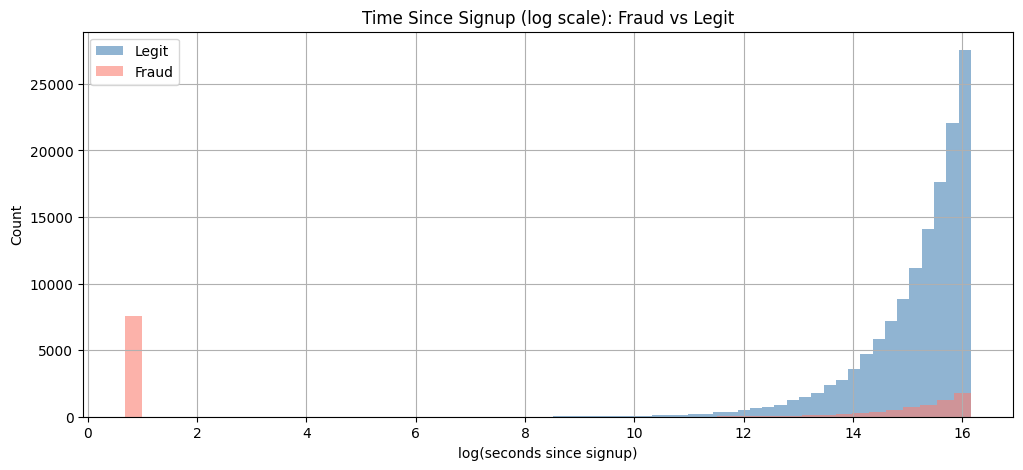


Fraud transactions within 1hr of signup:  53.7%
Legit transactions within 1hr of signup:  0.0%


In [24]:
# Calculate seconds between signup and purchase
df_merged['time_since_signup'] = (
    df_merged['purchase_time'] - df_merged['signup_time']
).dt.total_seconds()

# Let's see the distribution split by fraud vs legit
print("Time since signup (seconds):")
print(df_merged.groupby('class')['time_since_signup'].describe())

# Visualize it
fig, ax = plt.subplots(figsize=(12, 5))

# Use log scale because the range is huge (1 second to months)
df_merged[df_merged['class'] == 0]['time_since_signup'].apply(
    lambda x: np.log1p(x)  # log1p = log(1+x), handles zeros safely
).hist(bins=50, alpha=0.6, label='Legit', color='steelblue', ax=ax)

df_merged[df_merged['class'] == 1]['time_since_signup'].apply(
    lambda x: np.log1p(x)
).hist(bins=50, alpha=0.6, label='Fraud', color='salmon', ax=ax)

ax.set_title('Time Since Signup (log scale): Fraud vs Legit')
ax.set_xlabel('log(seconds since signup)')
ax.set_ylabel('Count')
ax.legend()
plt.show()

# What % of fraud happens within 1 hour of signup?
one_hour = 3600  # seconds
fraud_quick = df_merged[df_merged['class'] == 1]['time_since_signup'] < one_hour
legit_quick = df_merged[df_merged['class'] == 0]['time_since_signup'] < one_hour

print(f"\nFraud transactions within 1hr of signup:  {fraud_quick.mean()*100:.1f}%")
print(f"Legit transactions within 1hr of signup:  {legit_quick.mean()*100:.1f}%")

### 13. Hourly Fraud Patterns (Post-Merge)

Re-examine purchase-hour distribution on the enriched `df_merged` dataset and compute fraud rate by hour.

> Certain hours (typically late-night / early-morning UTC) show a markedly higher fraud rate, reinforcing `hour_of_day` as a useful feature.

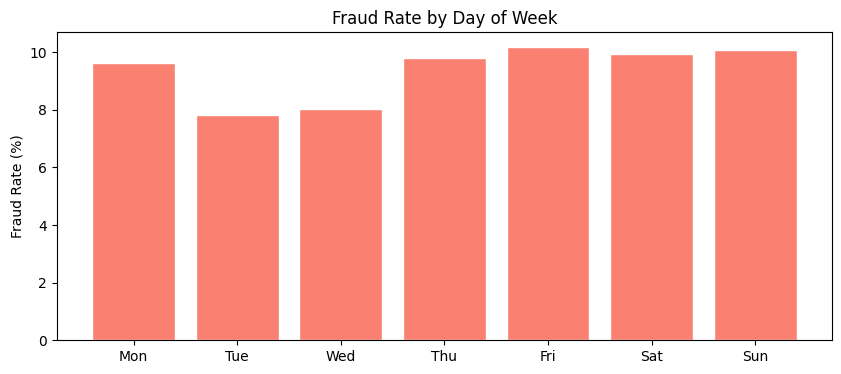

In [25]:
df_merged['hour_of_day'] = df_merged['purchase_time'].dt.hour
df_merged['day_of_week'] = df_merged['purchase_time'].dt.dayofweek
# dayofweek: 0 = Monday, 6 = Sunday

# Fraud rate by day of week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
fraud_by_day = df_merged.groupby('day_of_week')['class'].mean() * 100

plt.figure(figsize=(10, 4))
plt.bar(day_names, fraud_by_day.values, color='salmon', edgecolor='white')
plt.title('Fraud Rate by Day of Week')
plt.ylabel('Fraud Rate (%)')
plt.show()

### 14. Device Re-use Analysis

Flag `device_id` values that are shared across multiple distinct user accounts. A device used by many users is a strong indicator of account-farming fraud.

> **Key finding:** Some device IDs appear in tens or hundreds of accounts, which strongly correlates with fraudulent behaviour.

In [26]:
# Sort by device and time
df_merged = df_merged.sort_values(['device_id', 'purchase_time']).reset_index(drop=True)

# For each transaction, count how many previous transactions
# the same device made in the last hour
def compute_velocity(df, group_col, time_col, window_seconds=3600):
    """
    For each row, count transactions from the same group_col
    within the past window_seconds before this transaction.
    """
    counts = []
    # Group by device
    for _, group in df.groupby(group_col):
        times = group[time_col].values  # array of timestamps
        n = len(times)
        window = np.timedelta64(window_seconds, 's')
        for i in range(n):
            # Count how many previous transactions are within the window
            count = np.sum(times[max(0, i-100):i] >= times[i] - window)
            counts.append(count)
    return counts

# This takes a minute to run on 151k rows — that's normal
print("Computing transaction velocity... (may take 1-2 minutes)")
df_merged['device_tx_count_1hr'] = compute_velocity(
    df_merged, 'device_id', 'purchase_time', window_seconds=3600
)

print("Done!")
print(df_merged.groupby('class')['device_tx_count_1hr'].describe())

Computing transaction velocity... (may take 1-2 minutes)
Done!
          count      mean       std  min  25%  50%  75%   max
class                                                        
0      136961.0  0.000015  0.003821  0.0  0.0  0.0  0.0   1.0
1       14151.0  2.681083  3.643085  0.0  0.0  0.0  5.0  18.0


### 15. Feature Engineering & Scaling

Prepare the final feature matrix for modelling:

1. **Label-encode** categorical columns (`source`, `browser`, `sex`, `country`).
2. **Add engineered features**: `time_since_signup`, `hour_of_day`, `device_reuse_count`.
3. **Scale** numeric features with `StandardScaler`.

> The resulting matrix `X_scaled` and target vector `y` are ready for training classifiers such as Logistic Regression, Random Forest, or XGBoost.

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ── Step 1: Select final feature columns ──────────────────────────────
# Drop columns we don't need for modeling
cols_to_drop = [
    'user_id',          # just an ID, no signal
    'device_id',        # used for velocity already, too many unique values
    'signup_time',      # used to make time_since_signup already
    'purchase_time',    # used to make hour/day features already
    'ip_address',       # used to make country already
    'ip_int',           # intermediate column, not needed
    'lower_bound_ip_address',  # from the merge, not needed
    'upper_bound_ip_address',  # from the merge, not needed
]

df_model = df_merged.drop(columns=cols_to_drop)
print("Columns kept for modeling:")
print(df_model.columns.tolist())
print(f"Shape: {df_model.shape}")

Columns kept for modeling:
['purchase_value', 'source', 'browser', 'sex', 'age', 'class', 'hour_of_day', 'country', 'time_since_signup', 'day_of_week', 'device_tx_count_1hr']
Shape: (151112, 11)


In [28]:
# ── Step 2: One-hot encode categorical columns ────────────────────────
categorical_cols = ['source', 'browser', 'sex', 'country']

df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=False)

print(f"Shape after encoding: {df_model.shape}")
print("New columns created:")
print([c for c in df_model.columns if any(cat in c for cat in categorical_cols)])

Shape after encoding: (151112, 199)
New columns created:
['source_Ads', 'source_Direct', 'source_SEO', 'browser_Chrome', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'sex_F', 'sex_M', 'country_Afghanistan', 'country_Albania', 'country_Algeria', 'country_Angola', 'country_Antigua and Barbuda', 'country_Argentina', 'country_Armenia', 'country_Australia', 'country_Austria', 'country_Azerbaijan', 'country_Bahamas', 'country_Bahrain', 'country_Bangladesh', 'country_Barbados', 'country_Belarus', 'country_Belgium', 'country_Belize', 'country_Benin', 'country_Bermuda', 'country_Bhutan', 'country_Bolivia', 'country_Bonaire; Sint Eustatius; Saba', 'country_Bosnia and Herzegowina', 'country_Botswana', 'country_Brazil', 'country_British Indian Ocean Territory', 'country_Brunei Darussalam', 'country_Bulgaria', 'country_Burkina Faso', 'country_Burundi', 'country_Cambodia', 'country_Cameroon', 'country_Canada', 'country_Cape Verde', 'country_Cayman Islands', 'country_Chile', 'c

In [29]:
# ── Step 3: Separate features (X) from target (y) ────────────────────
# Think of X as all your input columns, y as what you're predicting

X = df_model.drop(columns=['class'])
y = df_model['class']

print(f"X shape: {X.shape}")   # features
print(f"y shape: {y.shape}")   # target
print(f"Fraud cases: {y.sum()} ({y.mean()*100:.1f}%)")

X shape: (151112, 198)
y shape: (151112,)
Fraud cases: 14151 (9.4%)


In [30]:
# ── Step 4: Train/Test Split ──────────────────────────────────────────
# We split BEFORE scaling — a very important rule

# stratify=y means the split preserves the 90/10 fraud ratio
# in both train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # makes results reproducible
    stratify=y            # preserve class balance
)

print(f"Training set:   {X_train.shape[0]} rows")
print(f"Test set:       {X_test.shape[0]} rows")
print(f"Train fraud %:  {y_train.mean()*100:.1f}%")
print(f"Test fraud %:   {y_test.mean()*100:.1f}%")

Training set:   120889 rows
Test set:       30223 rows
Train fraud %:  9.4%
Test fraud %:   9.4%


In [31]:
# ── Step 5: Scale numerical features ─────────────────────────────────
# IMPORTANT: fit the scaler on TRAIN only, then transform both
# Why? Because in real life you don't know the test data in advance
# Fitting on test data would be "cheating" — called data leakage

numerical_cols = [
    'purchase_value',
    'age', 
    'time_since_signup',
    'device_tx_count_1hr',
    'hour_of_day',
    'day_of_week'
]

scaler = StandardScaler()

# fit_transform on train: learn the mean/std AND apply scaling
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

# transform only on test: apply the SAME scaling learned from train
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("Scaling done!")
print("\nSample of scaled values (first 3 rows, numerical cols only):")
print(X_train[numerical_cols].head(3).round(3))

Scaling done!

Sample of scaled values (first 3 rows, numerical cols only):
        purchase_value    age  time_since_signup  device_tx_count_1hr  \
50372           -0.543 -1.406              1.140               -0.185   
95690           -0.161  1.610             -0.623               -0.185   
139038           0.221  0.914              1.644               -0.185   

        hour_of_day  day_of_week  
50372        -0.075       -1.504  
95690         1.659        0.491  
139038       -1.521       -1.005  


In [32]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(f"  Legit:  {(y_train == 0).sum()}")
print(f"  Fraud:  {(y_train == 1).sum()}")
print(f"  Ratio:  {(y_train == 0).sum() / (y_train == 1).sum():.1f}:1")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"  Legit:  {(y_train_smote == 0).sum()}")
print(f"  Fraud:  {(y_train_smote == 1).sum()}")
print(f"  Ratio:  {(y_train_smote == 0).sum() / (y_train_smote == 1).sum():.1f}:1")
print(f"  Total rows added: {len(X_train_smote) - len(X_train)}")

Before SMOTE:
  Legit:  109568
  Fraud:  11321
  Ratio:  9.7:1

After SMOTE:
  Legit:  109568
  Fraud:  109568
  Ratio:  1.0:1
  Total rows added: 98247


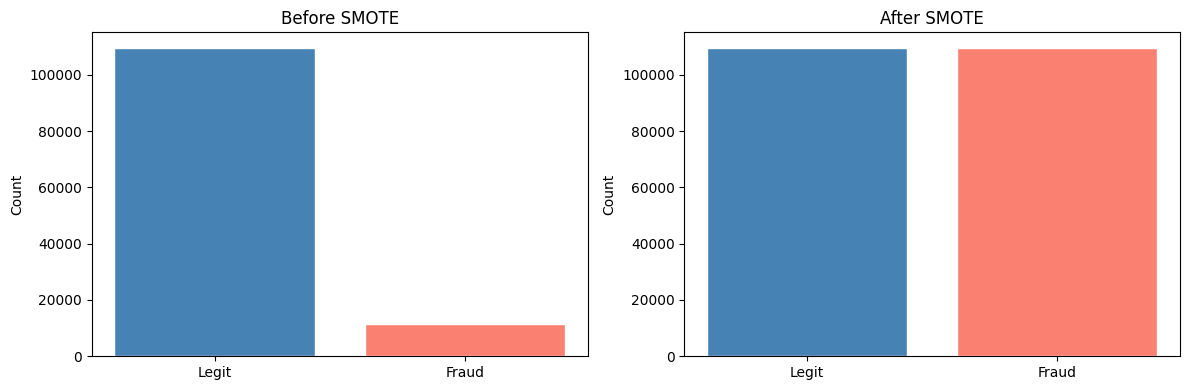

In [33]:
# Visualize before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before
axes[0].bar(['Legit', 'Fraud'], 
            [(y_train == 0).sum(), (y_train == 1).sum()],
            color=['steelblue', 'salmon'], edgecolor='white')
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')

# After  
axes[1].bar(['Legit', 'Fraud'],
            [(y_train_smote == 0).sum(), (y_train_smote == 1).sum()],
            color=['steelblue', 'salmon'], edgecolor='white')
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [34]:
# Save the processed datasets for use in Task 2
import os
os.makedirs('../data/processed', exist_ok=True)

# Save as CSV
X_train_smote.to_csv('../data/processed/X_train_fraud.csv', index=False)
X_test.to_csv('../data/processed/X_test_fraud.csv', index=False)
pd.Series(y_train_smote, name='class').to_csv('../data/processed/y_train_fraud.csv', index=False)
pd.Series(y_test, name='class').to_csv('../data/processed/y_test_fraud.csv', index=False)

print("✅ All processed files saved to data/processed/")
print(f"   X_train shape: {X_train_smote.shape}")
print(f"   X_test shape:  {X_test.shape}")

✅ All processed files saved to data/processed/
   X_train shape: (219136, 198)
   X_test shape:  (30223, 198)
